In [1]:
import pandas as pd
import numpy as np
import os
import mo_gymnasium as mo_gym
import gymnasium as gym
from env.user_sim import UserSimEnv
import env.simulate as sim_utils
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd
import utils
import process_data as dp
import mdp_utils
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from radar import radar_chart


%load_ext autoreload
%autoreload 2

Failed to read module file 'C:\Python311\Lib\urllib\parse.py' for module 'urllib.parse': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\shirl\Documents\Studie\2025-2026\Thesis\personalized-coping-challenges\.venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\shirl\Documents\Studie\2025-2026\Thesis\personalized-coping-challenges\.venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Python311\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1206, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1178, in _find_and_load
  File "<frozen impor

In [2]:
NUM_VALS_PER_FEATURE = [2, 2, 3]
NUM_FEATURES = len(NUM_VALS_PER_FEATURE)
NUM_USER_STATES = np.prod(NUM_VALS_PER_FEATURE)
NUM_CLUSTERS = 6
MAX_COUNT = 0
NUM_ACTIONS = NUM_CLUSTERS

cluster_col = 'cluster_all'
state_features = ['TIR', 'TIME_Q', 'GOOD']
feature_names = ['Tiredness', 'Time available', 'Usefulness belief']

reward_cols = ["obs_time", "obs_liked", "obs_pu", "r_expert", "r_diversity", "r_return"]
obj_names = ["Time Required", "Fun", "Perceived Usefulness", "Expert Usefulness", "Diversity"]

NUM_OBJECTIVES = len(reward_cols)

In [3]:
results_folder = 'C:\\Users\\shirl\\Documents\\Studie\\2025-2026\\Thesis\\personalized-coping-challenges\\results\\'

data_folder = 'C:\\Users\\shirl\\Documents\\Studie\\2025-2026\\Thesis\\personalized-coping-challenges\\data\\'

action_file = 'challenge_info.csv'
actions = pd.read_csv(data_folder + action_file)

filename = 'processed_samples.csv'
samples = pd.read_csv(os.path.join(data_folder, filename))

In [4]:
def get_cluster_size(df, cluster_vars, cluster_n, min_samples=5):
    """Determine optimal cluster size based on silhouette score and minimum cluster size.
    args:
    - df: DataFrame with z-scores for coping strategy categories.
    - cluster_vars: List of column names to use for clustering.
    - cluster_n: List of integers representing different cluster sizes to evaluate.
    - min_samples: Minimum number of samples required in the smallest cluster.
    returns:
    - best_k: Optimal number of clusters."""
 
    scaler = StandardScaler()
    X = scaler.fit_transform(df[cluster_vars])
    
    sil_scores = []
    smallest_cluster_sizes = []
 
    # calculate silhouette scores for different cluster sizes
    for k in cluster_n:
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(X)
 
        sil_scores.append(silhouette_score(X, labels))
 
        # get sample size of smallest cluster
        cluster_counts = pd.Series(labels).value_counts()
        smallest_cluster_sizes.append(cluster_counts.min())
 
    # get optimal cluster n based on silhouette score
    best_k = cluster_n[np.argmax(sil_scores)]
 
    # if smallest cluster size is below min_samples, check other cluster n
    if smallest_cluster_sizes[np.argmax(sil_scores)] < min_samples:
        # get cluster n with largest smallest cluster
        best_k = cluster_n[np.argmax(smallest_cluster_sizes)]

    print(f"Silhouette scores: {sil_scores}")
 
    return best_k

In [5]:
cluster_vars = ['usefulness', 'difficulty', 'time_spent']
overall_size = get_cluster_size(actions, cluster_vars, cluster_n=range(2, 13), min_samples=1)
print(f"Optimal cluster size: {overall_size} for cluster variables: {cluster_vars}")

cluster_vars = ['usefulness', 'difficulty', 'likedness']
overall_size = get_cluster_size(actions, cluster_vars, cluster_n=range(2, 13), min_samples=1)
print(f"Optimal cluster size: {overall_size} for cluster variables: {cluster_vars}")


Silhouette scores: [0.27274229318700427, 0.2589904241416322, 0.31519990436656514, 0.3314672506739503, 0.3262958702640834, 0.32957133851392145, 0.335709328558313, 0.32887897718416037, 0.32565004193377806, 0.2819523803527962, 0.2850448890645111]
Optimal cluster size: 8 for cluster variables: ['usefulness', 'difficulty', 'time_spent']
Silhouette scores: [0.3457741618972176, 0.28074834085897815, 0.24756588251765477, 0.2785804286248721, 0.2925687047092344, 0.29287090536072063, 0.24464842239070647, 0.2536375835302306, 0.25767057208154487, 0.2619995042428321, 0.23502999128899135]
Optimal cluster size: 2 for cluster variables: ['usefulness', 'difficulty', 'likedness']


In [6]:
actions[cluster_vars + ['expert_score']].corr()

,usefulness,difficulty,likedness,expert_score
usefulness,1.000000,-0.121515,0.661616,0.127850
difficulty,-0.121515,1.000000,-0.345354,0.467870
likedness,0.661616,-0.345354,1.000000,-0.187601
expert_score,0.127850,0.467870,-0.187601,1.000000


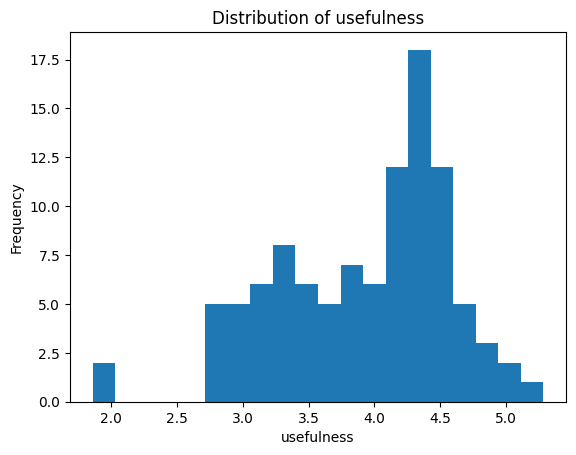

usefulness - Mean: 3.93, Std: 0.66


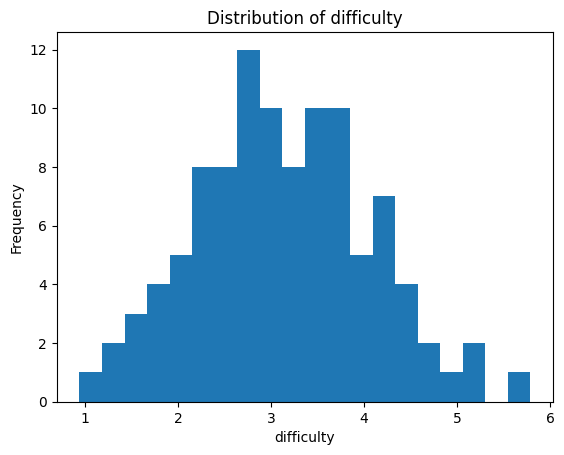

difficulty - Mean: 3.14, Std: 0.94


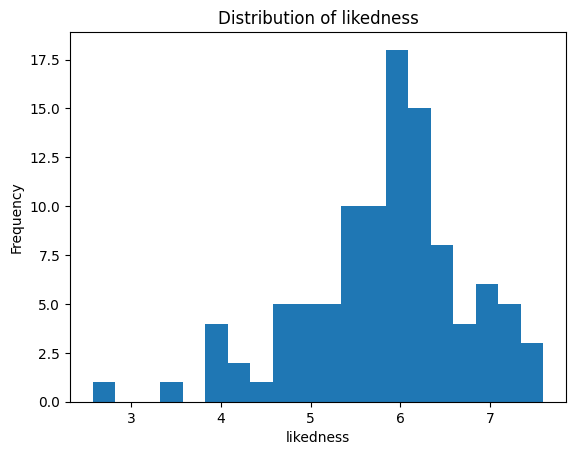

likedness - Mean: 5.83, Std: 0.91


In [8]:
for var in cluster_vars:
    plt.figure()
    plt.hist(actions[var], bins=20)
    plt.title(f"Distribution of {var}")
    plt.xlabel(var)
    plt.ylabel("Frequency")
    plt.show()
    # print mean and std
    print(f"{var} - Mean: {actions[var].mean():.2f}, Std: {actions[var].std():.2f}")

In [7]:
def plot_radar(labels, values, groups, title='Radar Chart'):
    """
    labels: list of strings (column names)
    values: 2D numpy array or list of lists (rows = groups, cols = labels)
    groups: list of strings (cluster/group names)
    """
    num_vars = len(labels)

    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

    for i, row in enumerate(values):
        data = np.concatenate((row, [row[0]]))
        ax.plot(angles, data, linewidth=2, linestyle='solid', label=groups[i], marker='o', markersize=4)
        ax.fill(angles, data, alpha=0.25)
    ax.set_yticklabels([])
    # 5. Fix the labels
    ax.set_theta_offset(np.pi / 2) # Start at the top
    ax.set_theta_direction(-1)     # Clockwise
    
    # Set the labels for each spoke
    ax.tick_params(pad=26)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=14)
    for label in ax.get_xticklabels():
        angle = label.get_position()[0]
        if abs(angle) < 0.1 or abs(angle - 2*np.pi) < 0.1:
            label.set_y(label.get_position()[1] + 0.13)
        elif np.isclose(abs(angle), np.pi):
            label.set_y(label.get_position()[1] + 0.13)

    # Add legend and title
    # plt.title(title, size=14, y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    
    return fig, ax

             usefulness  difficulty  likedness
cluster_all                                   
0              3.190661    3.778592   4.721349
1              3.898084    2.285301   6.078074
2              4.462160    3.583349   6.251603
Cluster 0:
['AC24', 'AC3', 'AC6', 'AF14', 'AF16', 'AF19', 'AF22', 'AF3', 'AF31', 'AF33', 'AF35', 'AF7', 'AF9', 'PO1', 'PO12', 'PO15', 'PO17', 'PO18', 'PO2', 'PO21', 'PO5', 'PO6', 'PO7', 'SP10']
category
acceptance          3
distraction        10
problem_solving    10
social_support      1
dtype: int64
Cluster 1:
['AC11', 'AC12', 'AC2', 'AC20', 'AC22', 'AF1', 'AF10', 'AF11', 'AF17', 'AF2', 'AF21', 'AF25', 'AF26', 'AF27', 'AF28', 'AF29', 'AF32', 'AF34', 'AF36', 'AF4', 'AF5', 'AF8', 'PO10', 'PO11', 'PO14', 'PO16', 'PO20', 'PO3', 'PO9', 'SP11', 'SP12', 'SP13', 'SP14', 'SP15', 'SP16', 'SP21', 'SP23', 'SP24', 'SP5']
category
acceptance          5
distraction        17
problem_solving     7
social_support     10
dtype: int64
Cluster 2:
['AC1', 'AC10', 'AC13', '

,usefulness,difficulty,likedness
cluster_all,,,
0,3.190661,3.778592,4.721349
1,3.898084,2.285301,6.078074
2,4.462160,3.583349,6.251603


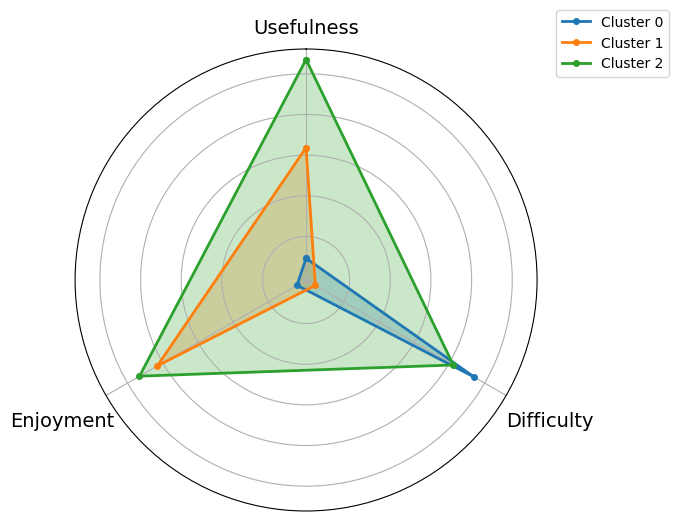

In [11]:
num_clusters = 3
cluster_vars = ['usefulness', 'difficulty', 'likedness']
actions_clustered = actions.copy()
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(actions_clustered[cluster_vars])
actions_clustered[cluster_col] = kmeans.fit_predict(X_scaled)

means = actions_clustered.groupby(cluster_col)[cluster_vars].mean()
print(means)
for cluster in range(num_clusters):
    print(f"Cluster {cluster}:")
    actions_in_cluster = actions_clustered[actions_clustered[cluster_col] == cluster]
    print(actions_in_cluster['challenge_id'].tolist())
    print(actions_in_cluster.groupby('category').size())
means = scaler.fit_transform(means)
plot_radar(labels = ['Usefulness', 'Difficulty', 'Enjoyment'], values = np.array(means), groups=["Cluster " + str(i) for i in range(num_clusters)], title='Mean Cluster Values')
# plt.show()
plt.savefig(results_folder + "figures/cluster_radar_chart.svg", bbox_inches='tight')
actions_clustered.groupby(cluster_col)[cluster_vars].mean()

             usefulness  difficulty  time_spent
cluster_all                                    
0              3.716306    4.242567   17.496633
1              4.459573    2.830619   10.730141
2              3.310277    2.597425    3.729015
Cluster 0:
['AC17', 'AC18', 'AC3', 'AC7', 'AF12', 'AF14', 'AF16', 'AF19', 'AF22', 'AF24', 'AF30', 'AF31', 'AF35', 'AF7', 'PO1', 'PO12', 'PO18', 'PO20', 'PO5', 'PO7', 'SP10', 'SP14', 'SP18', 'SP22', 'SP3', 'SP7', 'SP9']
category
acceptance          4
distraction        10
problem_solving     6
social_support      7
dtype: int64
Cluster 1:
['AC1', 'AC10', 'AC11', 'AC12', 'AC13', 'AC14', 'AC15', 'AC16', 'AC19', 'AC2', 'AC21', 'AC23', 'AC4', 'AC5', 'AC8', 'AC9', 'AF10', 'AF13', 'AF15', 'AF18', 'AF2', 'AF20', 'AF23', 'AF29', 'AF36', 'AF4', 'AF5', 'AF8', 'PO10', 'PO13', 'PO16', 'PO17', 'PO19', 'PO4', 'SP1', 'SP11', 'SP13', 'SP15', 'SP17', 'SP2', 'SP20', 'SP21', 'SP23', 'SP24', 'SP4', 'SP5', 'SP6', 'SP8']
category
acceptance         16
distraction        12

(<Figure size 600x600 with 1 Axes>, <PolarAxes: >)

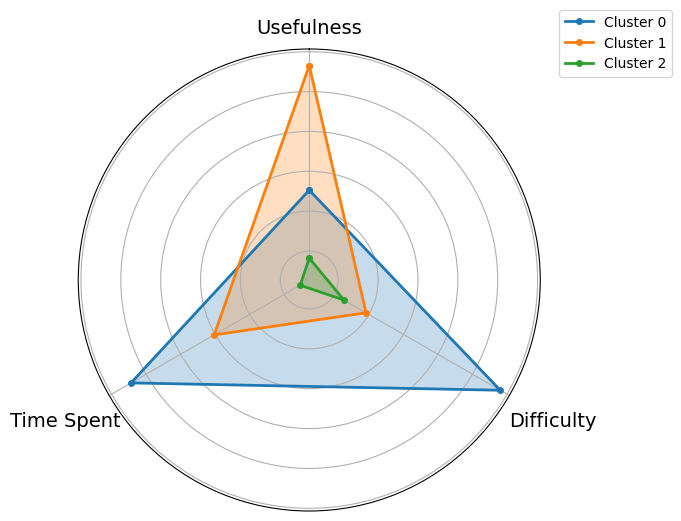

In [13]:
num_clusters = 3
cluster_vars = ['usefulness', 'difficulty', 'time_spent']
actions_clustered = actions.copy()
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(actions_clustered[cluster_vars])
actions_clustered[cluster_col] = kmeans.fit_predict(X_scaled)

means = actions_clustered.groupby(cluster_col)[cluster_vars].mean()
print(means)
for cluster in range(num_clusters):
    print(f"Cluster {cluster}:")
    actions_in_cluster = actions_clustered[actions_clustered[cluster_col] == cluster]
    print(actions_in_cluster['challenge_id'].tolist())
    print(actions_in_cluster.groupby('category').size())
means = scaler.fit_transform(means)
plot_radar(labels = ['Usefulness', 'Difficulty', 'Time Spent'], values = np.array(means), groups=["Cluster " + str(i) for i in range(num_clusters)], title='Mean Cluster Values')
# plt.show()

             usefulness  difficulty  time_spent  likedness  expert_score
cluster_all                                                             
0              3.287041    3.763377    6.149726   4.851760      0.847931
1              4.028326    2.456009    5.678124   6.107434      0.580000
2              4.499609    3.568570   22.690021   6.375374      0.894483
Cluster 0:
['AC17', 'AC20', 'AC24', 'AC3', 'AC6', 'AC7', 'AF14', 'AF16', 'AF19', 'AF22', 'AF28', 'AF3', 'AF31', 'AF33', 'AF35', 'AF7', 'AF9', 'PO1', 'PO12', 'PO15', 'PO17', 'PO18', 'PO2', 'PO21', 'PO5', 'PO6', 'PO7', 'SP10', 'SP9']
category
acceptance          6
distraction        11
problem_solving    10
social_support      2
dtype: int64
Cluster 1:
['AC11', 'AC12', 'AC16', 'AC19', 'AC2', 'AC21', 'AC22', 'AC23', 'AC5', 'AC9', 'AF1', 'AF10', 'AF11', 'AF15', 'AF17', 'AF2', 'AF20', 'AF21', 'AF25', 'AF26', 'AF27', 'AF32', 'AF34', 'AF36', 'AF4', 'AF5', 'AF6', 'AF8', 'PO10', 'PO11', 'PO14', 'PO16', 'PO20', 'PO3', 'PO4', 'PO9', 'SP11

(<Figure size 600x600 with 1 Axes>, <PolarAxes: >)

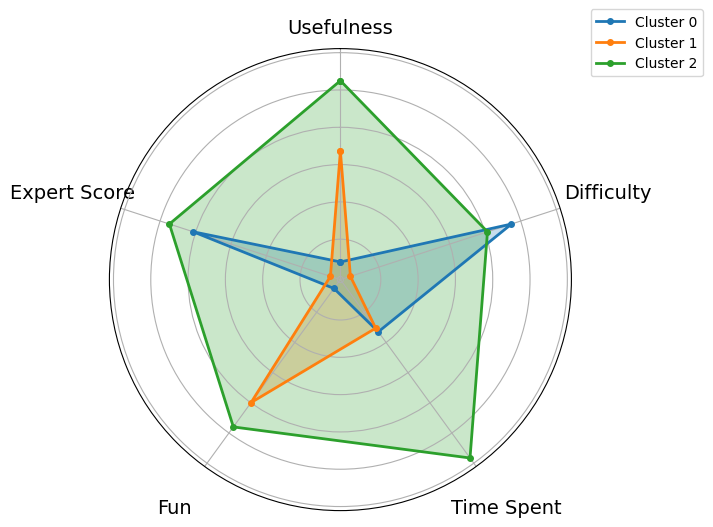

In [14]:
num_clusters = 3
cluster_vars = ['usefulness', 'difficulty', 'time_spent', 'likedness', 'expert_score']
actions_clustered = actions.copy()
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(actions_clustered[cluster_vars])
actions_clustered[cluster_col] = kmeans.fit_predict(X_scaled)

means = actions_clustered.groupby(cluster_col)[cluster_vars].mean()
print(means)
for cluster in range(num_clusters):
    print(f"Cluster {cluster}:")
    actions_in_cluster = actions_clustered[actions_clustered[cluster_col] == cluster]
    print(actions_in_cluster['challenge_id'].tolist())
    print(actions_in_cluster.groupby('category').size())
means = scaler.fit_transform(means)
plot_radar(labels = ['Usefulness', 'Difficulty', 'Time Spent', 'Fun', 'Expert Score'], values = np.array(means), groups=["Cluster " + str(i) for i in range(num_clusters)], title='Mean Cluster Values')


             usefulness  difficulty  time_spent  likedness
cluster_all                                               
0              3.363196    3.827617    7.268999   4.919813
1              4.149489    2.653324    6.019500   6.116670
2              4.522684    3.597720   39.240717   6.786193
Cluster 0:
['AC17', 'AC18', 'AC24', 'AC3', 'AC6', 'AC7', 'AF14', 'AF16', 'AF19', 'AF22', 'AF28', 'AF3', 'AF30', 'AF31', 'AF33', 'AF34', 'AF35', 'AF7', 'AF9', 'PO1', 'PO12', 'PO15', 'PO17', 'PO18', 'PO2', 'PO20', 'PO21', 'PO5', 'PO6', 'PO7', 'SP10', 'SP9']
category
acceptance          6
distraction        13
problem_solving    11
social_support      2
dtype: int64
Cluster 1:
['AC1', 'AC10', 'AC11', 'AC12', 'AC13', 'AC14', 'AC15', 'AC16', 'AC19', 'AC2', 'AC20', 'AC21', 'AC22', 'AC23', 'AC4', 'AC5', 'AC8', 'AC9', 'AF1', 'AF10', 'AF11', 'AF15', 'AF17', 'AF2', 'AF20', 'AF21', 'AF25', 'AF26', 'AF27', 'AF29', 'AF32', 'AF36', 'AF4', 'AF5', 'AF6', 'AF8', 'PO10', 'PO11', 'PO13', 'PO14', 'PO16', 'PO19', 'PO

(<Figure size 600x600 with 1 Axes>, <PolarAxes: >)

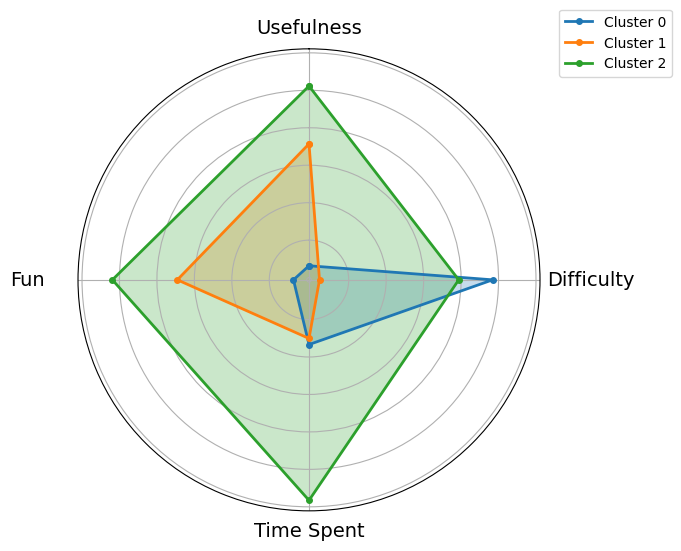

In [16]:
num_clusters = 3
cluster_vars = ['usefulness', 'difficulty', 'time_spent', 'likedness']
actions_clustered = actions.copy()
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(actions_clustered[cluster_vars])
actions_clustered[cluster_col] = kmeans.fit_predict(X_scaled)

means = actions_clustered.groupby(cluster_col)[cluster_vars].mean()
print(means)
for cluster in range(num_clusters):
    print(f"Cluster {cluster}:")
    actions_in_cluster = actions_clustered[actions_clustered[cluster_col] == cluster]
    print(actions_in_cluster['challenge_id'].tolist())
    print(actions_in_cluster.groupby('category').size())
means = scaler.fit_transform(means)
plot_radar(labels = ['Usefulness', 'Difficulty', 'Time Spent', 'Fun'], values = np.array(means), groups=["Cluster " + str(i) for i in range(num_clusters)], title='Mean Cluster Values')
